In [2]:
#1. Safe Plotting with Try-Except Blocks 

import seaborn as sns
import matplotlib.pyplot as plt

try:
    top_artists = df['artist'].value_counts().head(10).index

    sns.barplot(
        x='popularity',
        y='artist',
        data=df[df['artist'].isin(top_artists)],
        estimator='mean',
        errorbar=None
    )

    plt.title('Average Popularity of Top 10 Artists')
    plt.xlabel('Average Popularity')
    plt.ylabel('Artist')

    plt.show()

except KeyError as e:
    print(f"Column not found: {e}")

except ValueError as e:
    print(f"Value error during plotting: {e}")

except Exception as e:
    print(f"Unexpected error: {e}")

Unexpected error: name 'df' is not defined


In [5]:
import pandas as pd

df = pd.read_csv("spotify_top_1000_tracks.csv")  # replace with your actual filename

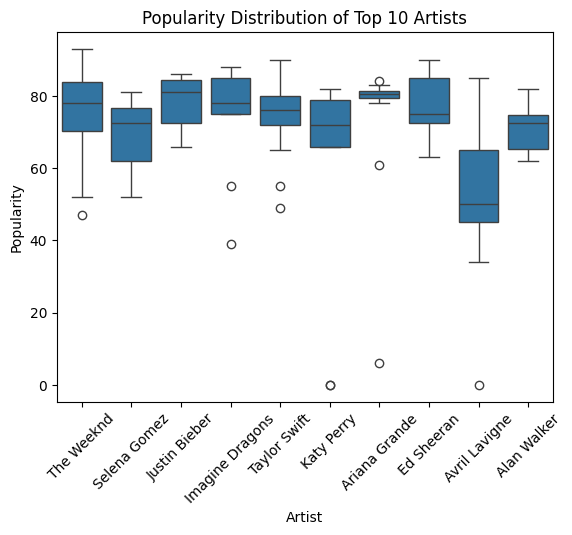

In [6]:
#2. Validate and Clean Data Before Plotting 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure clean column names
df.columns = df.columns.str.strip()

# Check required real columns
if 'artist' in df.columns and 'popularity' in df.columns and pd.api.types.is_numeric_dtype(df['popularity']):

    # remove missing values
    df_clean = df.dropna(subset=['artist', 'popularity'])

    # take top 10 artists for readability
    top_artists = df_clean['artist'].value_counts().head(10).index
    df_filtered = df_clean[df_clean['artist'].isin(top_artists)]

    sns.boxplot(x='artist', y='popularity', data=df_filtered)

    plt.xticks(rotation=45)
    plt.title("Popularity Distribution of Top 10 Artists")
    plt.xlabel("Artist")
    plt.ylabel("Popularity")

    plt.show()

else:
    print("Check column names or data types before plotting.")

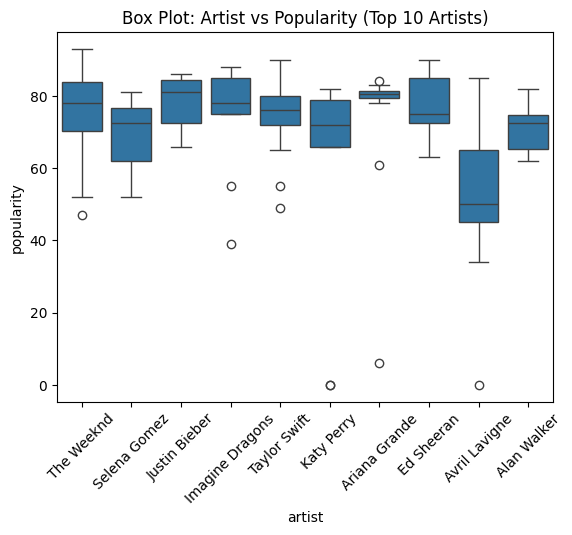

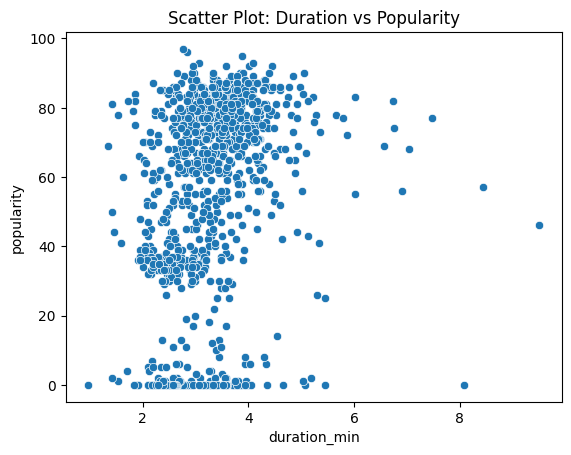

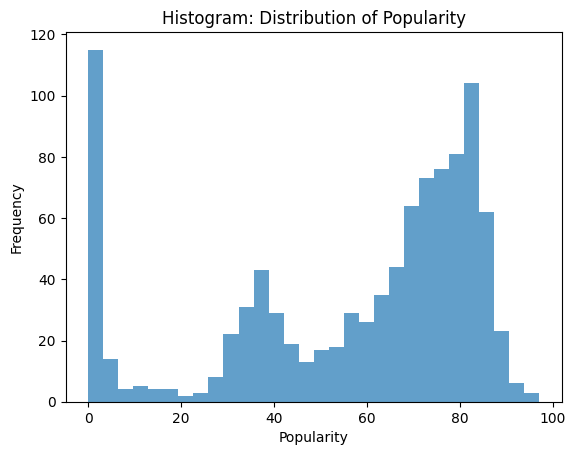

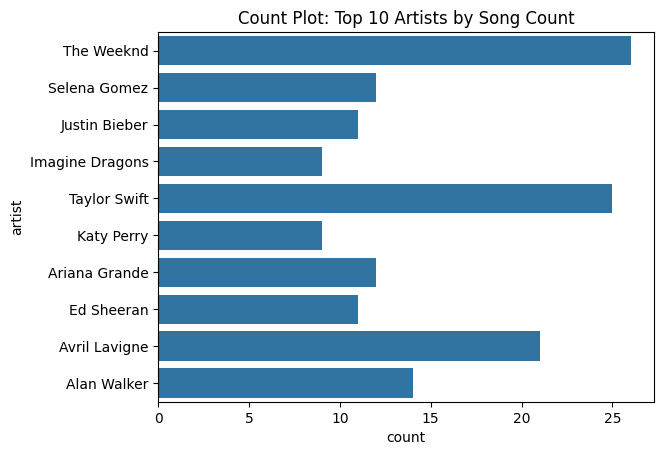

In [8]:
# 3. Choose the Right Plot for Your Data 
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure column names are clean
df.columns = df.columns.str.strip()

# Ensure numeric columns are properly converted
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')
df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce')

# Drop missing values for safe plotting
df_clean = df.dropna()

# -----------------------------
# 1. Categorical vs Numerical
# Example: Artist vs Popularity (Top 10 artists)
# -----------------------------
top_artists = df_clean['artist'].value_counts().head(10).index
df_top = df_clean[df_clean['artist'].isin(top_artists)]

plt.figure()
sns.boxplot(x='artist', y='popularity', data=df_top)
plt.xticks(rotation=45)
plt.title("Box Plot: Artist vs Popularity (Top 10 Artists)")
plt.show()


# -----------------------------
# 2. Numerical vs Numerical
# Example: Duration vs Popularity
# -----------------------------
plt.figure()
sns.scatterplot(x='duration_min', y='popularity', data=df_clean)
plt.title("Scatter Plot: Duration vs Popularity")
plt.show()


# -----------------------------
# 3. Single Numerical Series
# Example: Distribution of Popularity
# -----------------------------
plt.figure()
df_clean['popularity'].plot(kind='hist', bins=30, alpha=0.7)
plt.title("Histogram: Distribution of Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.show()


# -----------------------------
# 4. Categorical Series
# Example: Top Artists Count
# -----------------------------
plt.figure()
sns.countplot(y='artist', data=df_top)
plt.title("Count Plot: Top 10 Artists by Song Count")
plt.show()

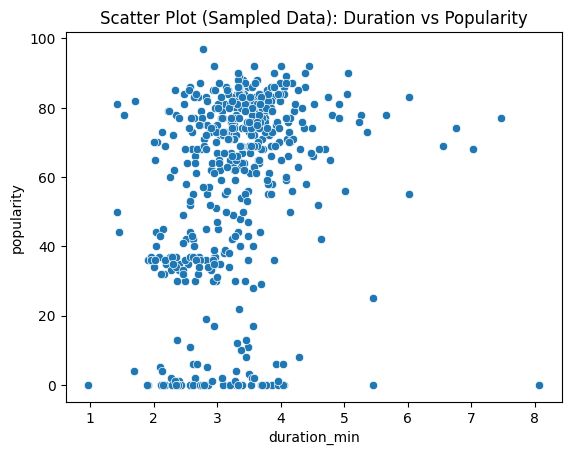

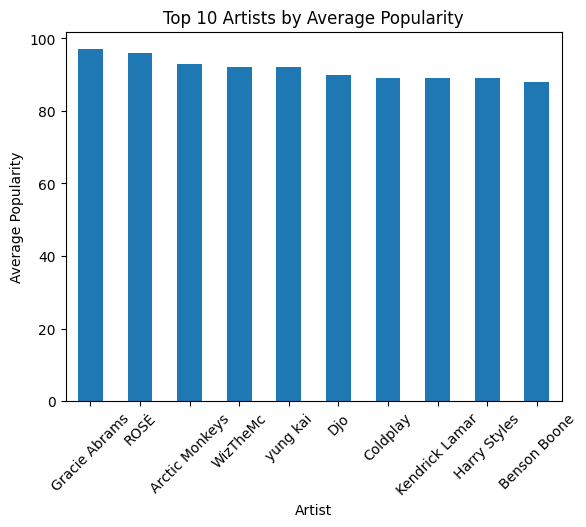

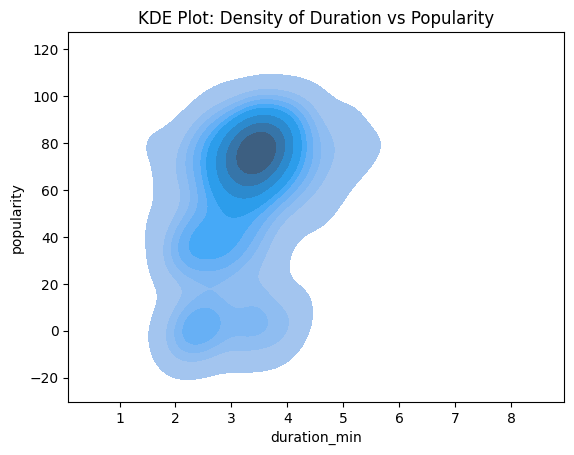

In [10]:
# 4. Handle Large Datasets Efficiently 
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure clean data
df.columns = df.columns.str.strip()

df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')
df['duration_min'] = pd.to_numeric(df['duration_min'], errors='coerce')

df_clean = df.dropna()

# -----------------------------
# 1. Sampling (reduces dataset size for faster plotting)
# -----------------------------
df_sample = df_clean.sample(500) if len(df_clean) > 500 else df_clean

plt.figure()
sns.scatterplot(
    x='duration_min',
    y='popularity',
    data=df_sample
)
plt.title("Scatter Plot (Sampled Data): Duration vs Popularity")
plt.show()


# -----------------------------
# 2. Aggregation (grouping for clearer insights)
# -----------------------------
avg_popularity = df_clean.groupby('artist')['popularity'].mean().sort_values(ascending=False).head(10)

plt.figure()
avg_popularity.plot(kind='bar')
plt.title("Top 10 Artists by Average Popularity")
plt.xlabel("Artist")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)
plt.show()


# -----------------------------
# 3. Specialized Plot (for dense data)
# -----------------------------
plt.figure()
sns.kdeplot(
    data=df_sample,
    x='duration_min',
    y='popularity',
    fill=True
)
plt.title("KDE Plot: Density of Duration vs Popularity")
plt.show()

C:\Users\Ayisha Claire\AppData\Local\Temp\ipykernel_22496\2446524364.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


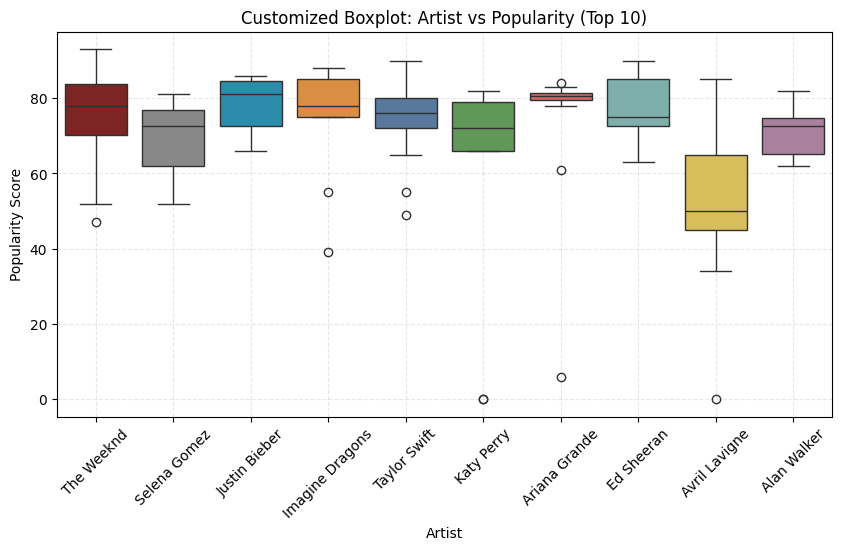

In [11]:
# 5. Customize Plots Wisely
import seaborn as sns
import matplotlib.pyplot as plt

# Clean data
df.columns = df.columns.str.strip()
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

df_clean = df.dropna(subset=['artist', 'popularity'])

# Take top 10 artists for readability
top_artists = df_clean['artist'].value_counts().head(10).index
df_top = df_clean[df_clean['artist'].isin(top_artists)]

# Custom boxplot
plt.figure(figsize=(10, 5))

sns.boxplot(
    x='artist',
    y='popularity',
    data=df_top,
    palette=['#8C1515', '#888888', '#1598C1', '#F28E2B', '#4E79A7',
             '#59A14F', '#E15759', '#76B7B2', '#EDC948', '#B07AA1']
)

plt.title("Customized Boxplot: Artist vs Popularity (Top 10)")
plt.xlabel("Artist")
plt.ylabel("Popularity Score")

plt.grid(True, linestyle='--', alpha=0.3)

plt.xticks(rotation=45)

plt.show() 